In [1]:
import numpy as np
from matplotlib import pyplot as plt
import datetime
import Bayesian_Methods as Bayes
from functools import partial
import sys
import Parameters as Pars
from Full_Par_Method import Parameter_Processing
import Full_Par_Method
from multiprocess import Pool
from dynesty import DynamicNestedSampler, sampler, plotting
from getdist import plots, MCSamples
import emcee, corner

In [2]:
ndim = 6
par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])
par_ranges = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))

In [20]:
def Likelihood_Wrapper(parameters):
    par_ranges = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
    if not all(np.where((parameters > par_ranges[0]) & (parameters < par_ranges[1]), True, False)): 
        return -np.inf
    else: 
        par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])
        par_dict = {key: value for key, value in zip(par_names,parameters)}
        t1 = Parameter_Processing(par_dict, load_strain = False)
        Likelihood = t1.Quick_Likelihood()
    return np.log(float(Likelihood))

In [21]:
def Prior_Wrapper(u):
    par_ranges = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
    return Pars.Parameter_Uniform_Emcee(u,par_ranges[1],par_ranges[0])

In [26]:
log_probq = np.load(f'Emcee_Samples/pars_{par_names}_quick_32000_emcee.npz', allow_pickle=True)['log_prob']
chainsq = np.load(f'Emcee_Samples/pars_{par_names}_quick_32000_emcee.npz', allow_pickle=True)['chains']
burnq = int(len(chains)/2)

In [27]:
rchainsq = chainsq[burnq:].reshape(-1,chainsq[burnq:].shape[-1])

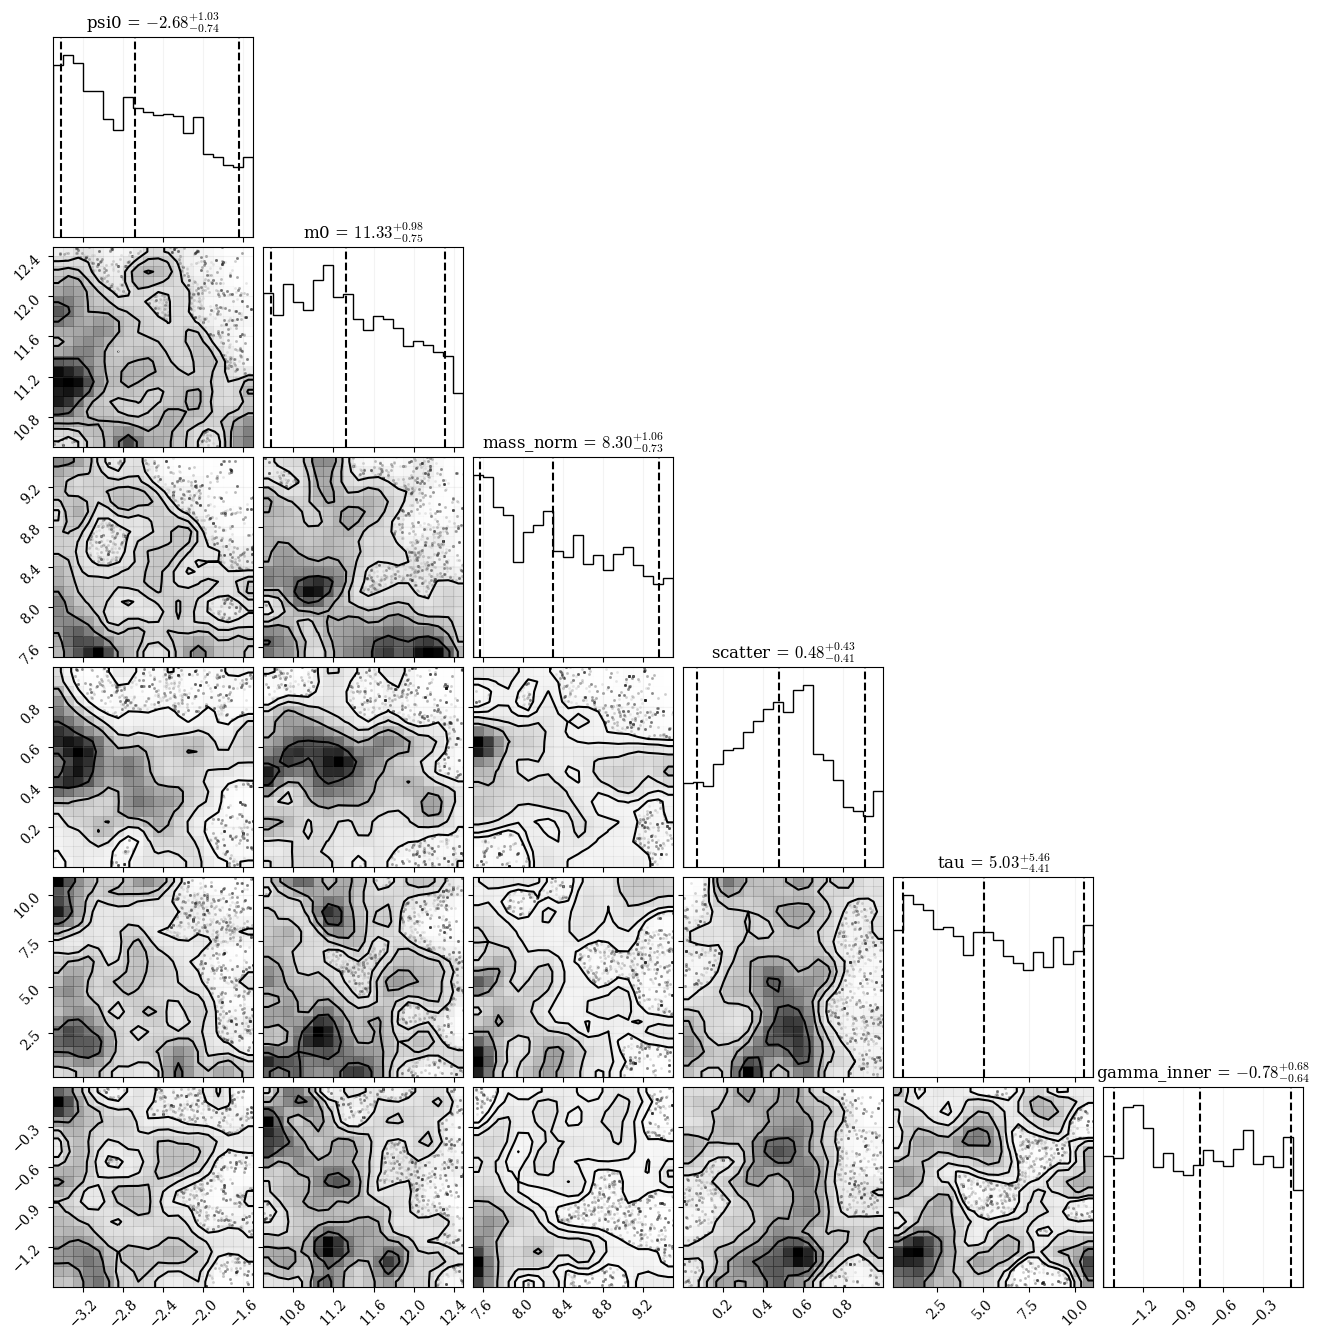

In [28]:
corner.corner(rchainsq,smooth=1, titles=par_names,show_titles=1,quantiles=[0.05,0.5,0.95])
plt.show()

In [5]:
log_probf = np.load(f'Emcee_Samples/pars_{par_names}_full_32000_50R.npz', allow_pickle=True)['log_prob']
chainsf = np.load(f'Emcee_Samples/pars_{par_names}_full_32000_50R.npz', allow_pickle=True)['chains']
burnf = int(len(chainsf)/2)

In [6]:
rchainsf = chainsf[burnf:].reshape(-1,chainsf[burnf:].shape[-1])

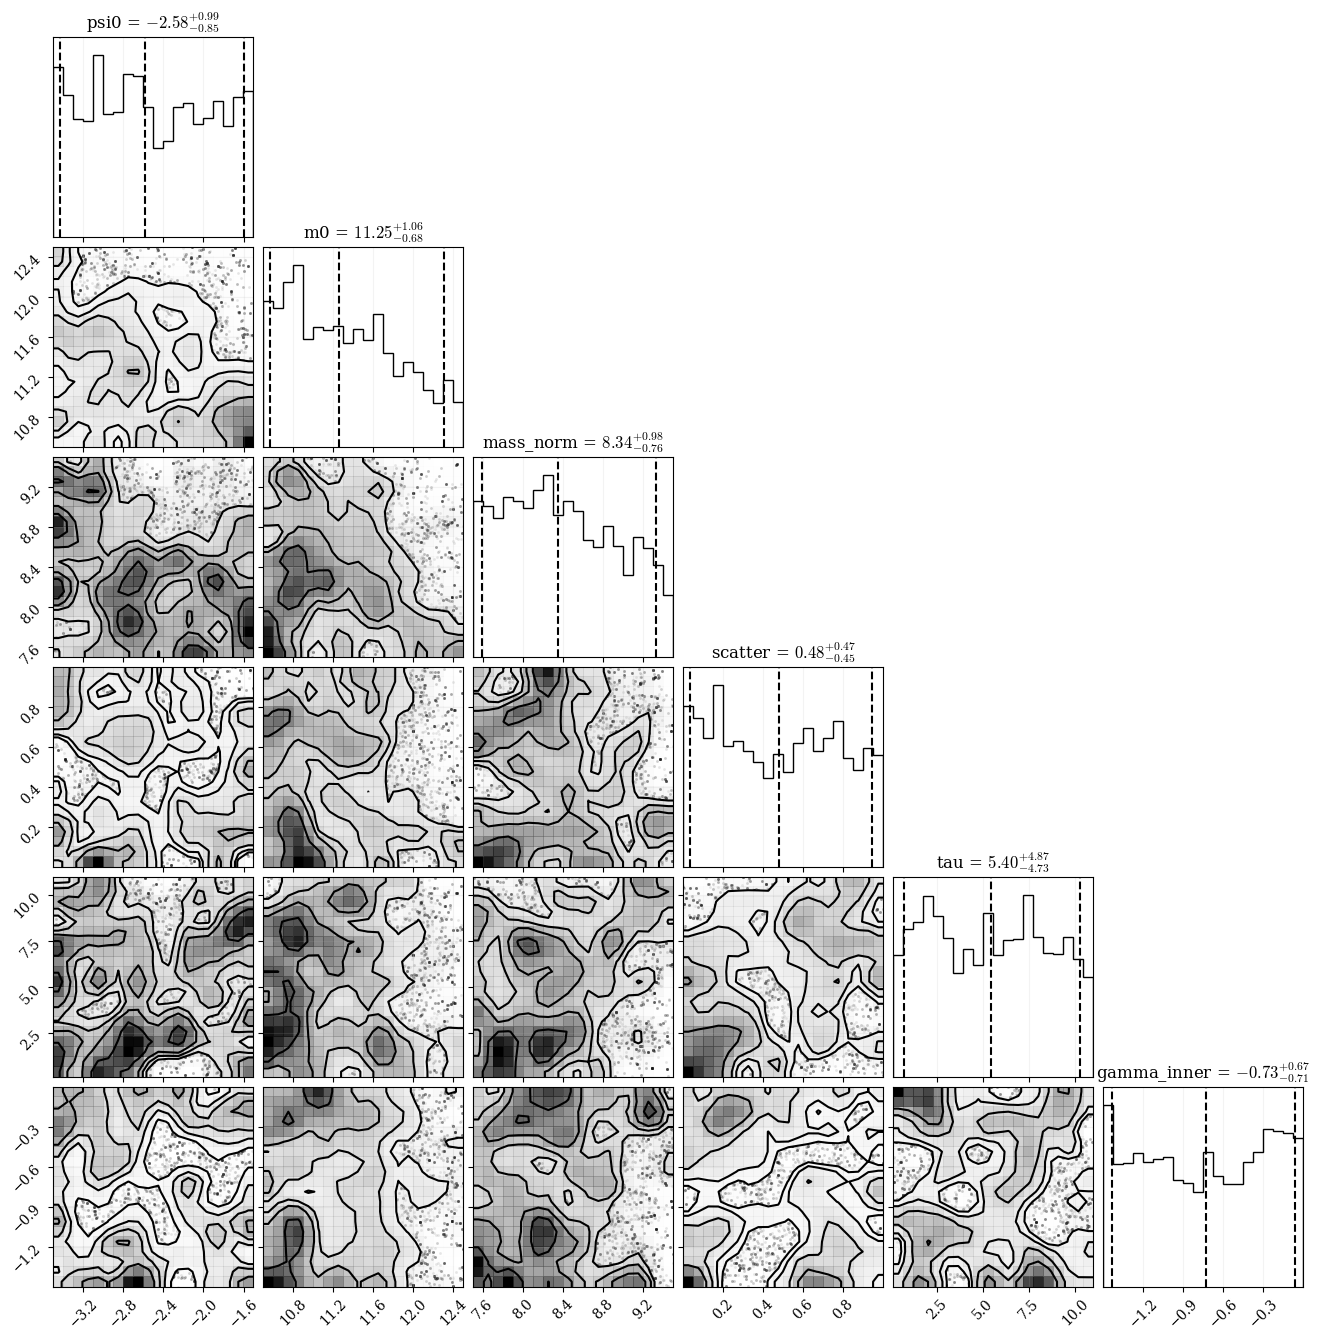

In [7]:
corner.corner(rchainsf,smooth=1, titles=par_names,show_titles=1,quantiles=[0.05,0.5,0.95])
plt.show()